# London Fire Brigade: mobilisation to arrival
**C1 | Business Intelligence | 29 September 2026**  
Matias Muñoz Hoffmann and Clemente Ibarra

Academic diagnostic analysis of published records, with AI-assisted preparation.
See PROCESS_LOG.md for disclosure and outstanding team review.

## Context & Methods
**Question:** Which boroughs and dispatch hours merit a review of long mobilisation-to-arrival times?
**Decision:** prioritise investigation; no automatic staffing or dispatch recommendation.
**Population:** published pumping-appliance mobilisations dispatched in 2023-2024.
**Unit:** one mobilisation, not one incident. **KPI:** P90 attendance seconds / 60.

### Key assumptions and limits
- GMT follows the source dictionary. Hour refers to dispatch, not call receipt.
- 31 December 2024 is absent; December and annual 2024 totals are partial.
- The extract contains only Initial records and durations at most 20 minutes.
- [LFB methodology](https://www.london-fire.gov.uk/media/8863/foia84201-response-times-of-fire-brigades-and-data-collation-response.pdf)
  documents >20-minute exclusions for performance calculations; exact CSV selection rules are not fully verified.
- Unknown geography remains visible. Comparisons are unadjusted for incident mix and distance.
- No models are required for this C1; C2 will extend the analysis after feedback.

## Data
[Official dataset and metadata](https://data.london.gov.uk/dataset/london-fire-brigade-mobilisation-records-24r65).
Download first with `python scripts/download_data.py`. Hashes identify the exact original snapshot.


In [1]:
from pathlib import Path
import sys, json, io, contextlib
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'scripts'))
from analysis import run
display(pd.DataFrame(json.loads((ROOT/'data/source_manifest.json').read_text())).T)


,url,retrieved_utc,bytes,sha256,publisher,license_as_listed
mobilisations_2021_2024.csv,https://data.london.gov.uk/download/24r65/3ff2...,2026-09-23T02:52:18.339147+00:00,168034240,f18f9ea1943ce54ac58e3429ed2d242f9d1fa714d3a556...,London Fire Brigade / London Datastore,Open Government Licence v2
mobilisations_metadata.xlsx,https://data.london.gov.uk/download/24r65/0eaa...,2026-09-23T02:52:19.851144+00:00,11693,dec9ca5bf2feb358b6da5dc32af55610c12b7a8f55a0e8...,London Fire Brigade / London Datastore,Open Government Licence v2


### Reproducible audit and cleaning
The companion `scripts/analysis.py` is part of the submission and contains all transformations.
It reads the original snapshot, profiles missingness and coverage, parses dates/numbers,
removes exact duplicate rows and quarantines conflicting IDs. No target imputation or
arbitrary outlier removal is applied. Missing partial durations do not invalidate a consistent total.
The pipeline exports every reconciliation and produces the charts below.


In [2]:
with contextlib.redirect_stdout(io.StringIO()):
    raw, period, clean, tables, audit, summary = run()
display(pd.read_csv(ROOT/'outputs/row_flow.csv'))
display(pd.DataFrame({'exclusion_flag': audit['exclusion_flags_overlap'].keys(),
                      'rows': audit['exclusion_flags_overlap'].values()}))


,stage,rows
0,Source 2021-2024,727857
1,After exact deduplication,723935
2,Selected dispatch dates 2023-2024,384643
3,KPI eligible,384627


,exclusion_flag,rows
0,missing_id,0
1,conflicting_id,16
2,missing_or_negative_attendance,0
3,invalid_arrival,0
4,attendance_disagrees_timestamp,0


## tl;dr

In [3]:
display(Markdown(f"""The selected published population contains **{len(clean):,} eligible mobilisations**
across **{clean.IncidentNumber.nunique():,} distinct incident IDs**. Median attendance is
**{summary['median_min']:.2f} minutes** and P90 is **{summary['p90_min']:.2f} minutes**.
The original four-year file contains {audit['exact_duplicates_removed']:,} exact duplicate rows;
{audit['excluded_kpi_rows']} selected-period rows are excluded by the KPI rules.
**Scope caveat:** the missing final day and the observed 20-minute ceiling prevent claims
about complete annual demand or the unobserved extreme tail."""))


The selected published population contains **384,627 eligible mobilisations**
across **248,225 distinct incident IDs**. Median attendance is
**5.65 minutes** and P90 is **9.20 minutes**.
The original four-year file contains 3,922 exact duplicate rows;
16 selected-period rows are excluded by the KPI rules.
**Scope caveat:** the missing final day and the observed 20-minute ceiling prevent claims
about complete annual demand or the unobserved extreme tail.

### Quality profile and missingness

In [4]:
display(pd.read_csv(ROOT/'outputs/raw_profile.csv').sort_values('missing_pct',ascending=False))
display(pd.DataFrame(audit['parse_failures_all_years'].items(),columns=['field','parse_failures']))

,column,missing_n,missing_pct,distinct
15,DateAndTimeReturned,727857,100.000000,0
22,DelayCodeId,544717,74.838464,10
23,DelayCode_Description,544717,74.838464,10
3,WardName,3499,0.480726,1283
12,TravelTimeSeconds,3227,0.443356,1166
11,TurnoutTimeSeconds,3222,0.442669,710
9,DateAndTimeMobile,3203,0.440059,713333
2,BoroughName,2734,0.375623,37
18,DeployedFromLocation,505,0.069382,2
14,DateAndTimeLeft,280,0.038469,719002


,field,parse_failures
0,DateAndTimeMobilised,0
1,DateAndTimeMobile,0
2,DateAndTimeArrived,0
3,DateAndTimeLeft,0
4,DateAndTimeReturned,0
5,CalYear,0
6,HourOfCall,0
7,TurnoutTimeSeconds,0
8,TravelTimeSeconds,0
9,AttendanceTimeSeconds,0


Missing return times and missing delay codes are not filled with zero. A missing delay
description means unknown/unrecorded, not proven absence of a delay. Geography is not imputed.
The older dictionary lacks BoroughName and WardName; they are used as published labels.


In [5]:
display(pd.read_csv(ROOT/'outputs/exclusions_by_borough.csv').sort_values('excluded_pct',ascending=False).head(10))
display(pd.DataFrame({'metric':['missing geography','components unavailable/inconsistent','zero duration'],
    'eligible_rows':[audit['missing_borough_eligible'], audit['component_inconsistent_or_missing_eligible'],audit['zero_attendance_eligible']]}))
coverage=pd.read_csv(ROOT/'outputs/daily_coverage.csv')
display(coverage[coverage.mobilisations.eq(0)])


,borough,total,eligible,excluded_pct
28,SLOUGH,1,0,100.000000
5,BUCKINGHAMSHIRE,1,0,100.000000
32,Unknown,1290,1288,0.155039
24,MERTON,5982,5980,0.033434
18,HOUNSLOW,9413,9411,0.021247
8,CROYDON,17117,17114,0.017526
22,LAMBETH,17213,17210,0.017429
1,BARNET,12813,12811,0.015609
3,BRENT,12169,12169,0.000000
2,BEXLEY,6997,6997,0.000000


,metric,eligible_rows
0,missing geography,1288
1,components unavailable/inconsistent,1816
2,zero duration,1


,Unnamed: 0,mobilisations
730,2024-12-31 00:00:00+00:00,0


### Verification of the KPI

In [6]:
elapsed=(clean.DateAndTimeArrived-clean.DateAndTimeMobilised).dt.total_seconds()
assert (elapsed-clean.AttendanceTimeSeconds).abs().le(1).all()
assert clean.ResourceMobilisationId.is_unique
assert len(period)==len(clean)+audit['excluded_kpi_rows']
assert sum(tables['monthly']['n'])==len(clean)
display(pd.Series(summary, name='value').to_frame())
display(Markdown(f"Independent sorted-value P90: **{audit['independent_p90_min']:.2f} minutes**."))


,value
n,384627.000000
median_min,5.650000
p90_min,9.200000
mean_min,6.028076
p99_min,14.450000
max_min,20.000000
initial_mobilisations_n,384627.000000
initial_mobilisations_p90_min,9.200000
positive_only_p90_min,9.200000
known_borough_p90_min,9.183333


Independent sorted-value P90: **9.20 minutes**.

## Results
All figures refer to eligible published mobilisations in the requested 2023-2024 window;
31 December 2024 is absent. Published records do not measure all actual service demand.


### Distribution

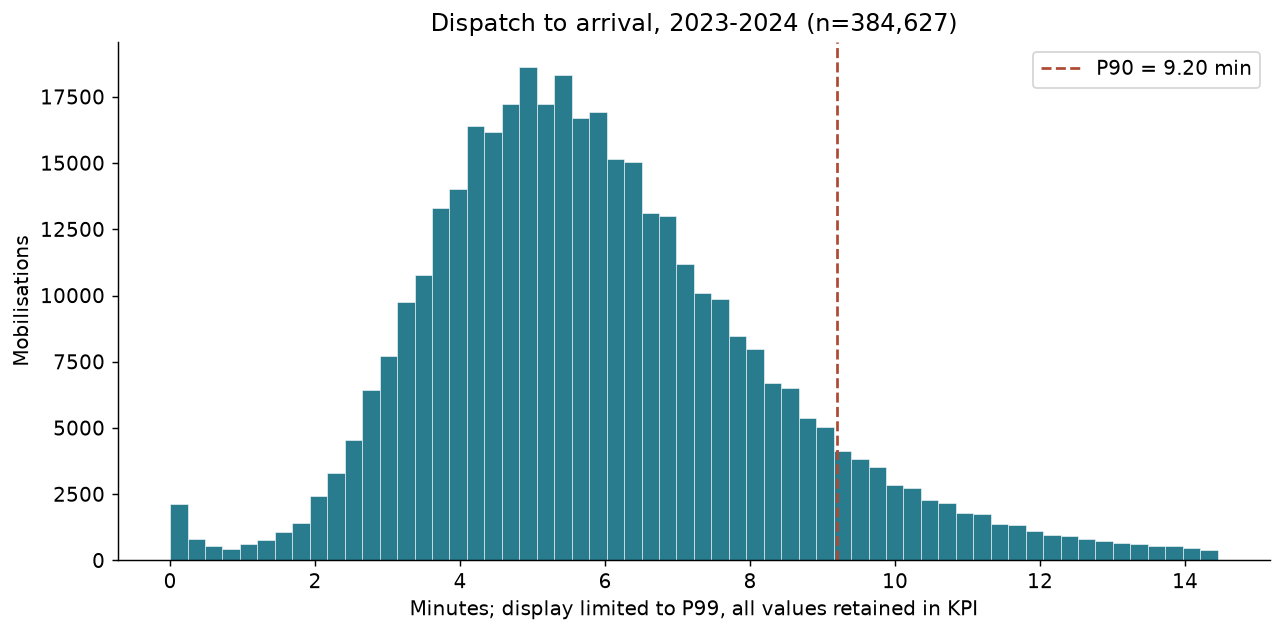

In [7]:
display(Image(filename=str(ROOT/'outputs/figures/01_distribution.png')))

The histogram shows the centre and right tail up to P99 for legibility. The KPI retains every eligible observation, including those outside the displayed range.

### Density

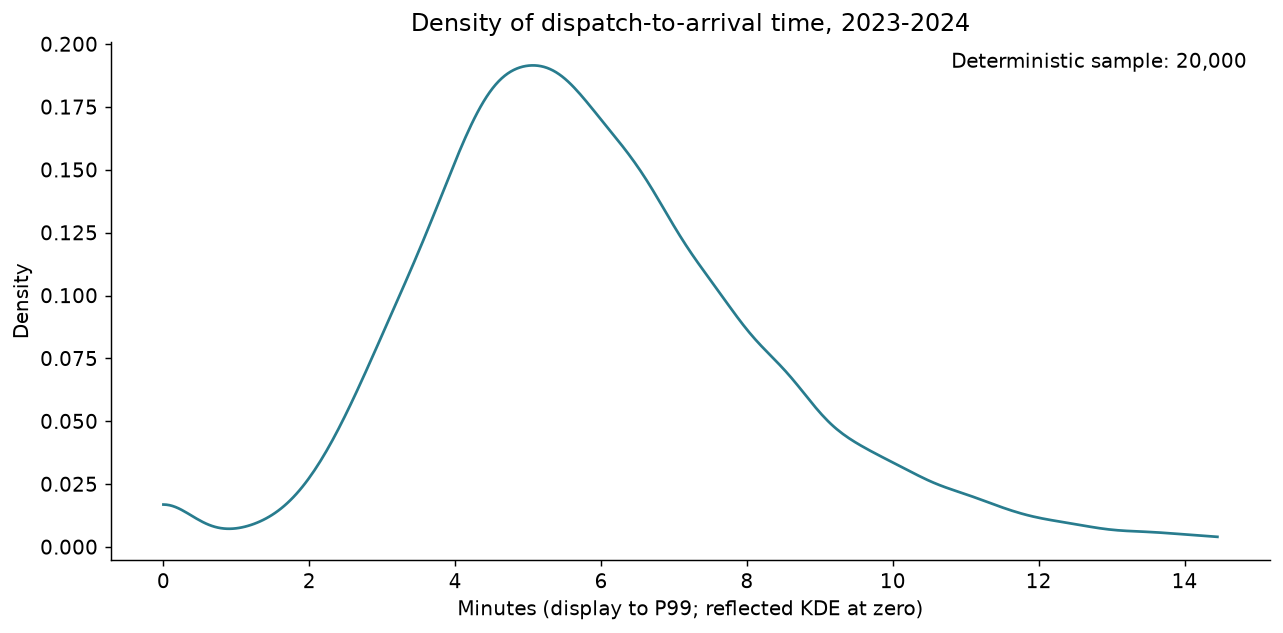

In [8]:
display(Image(filename=str(ROOT/'outputs/figures/02_density.png')))

The KDE uses a deterministic sample of 20,000 records and reflection at zero. It is a smoothed display, not a fitted predictive model or an estimate of unobserved >20-minute responses.

### Entire observed tail

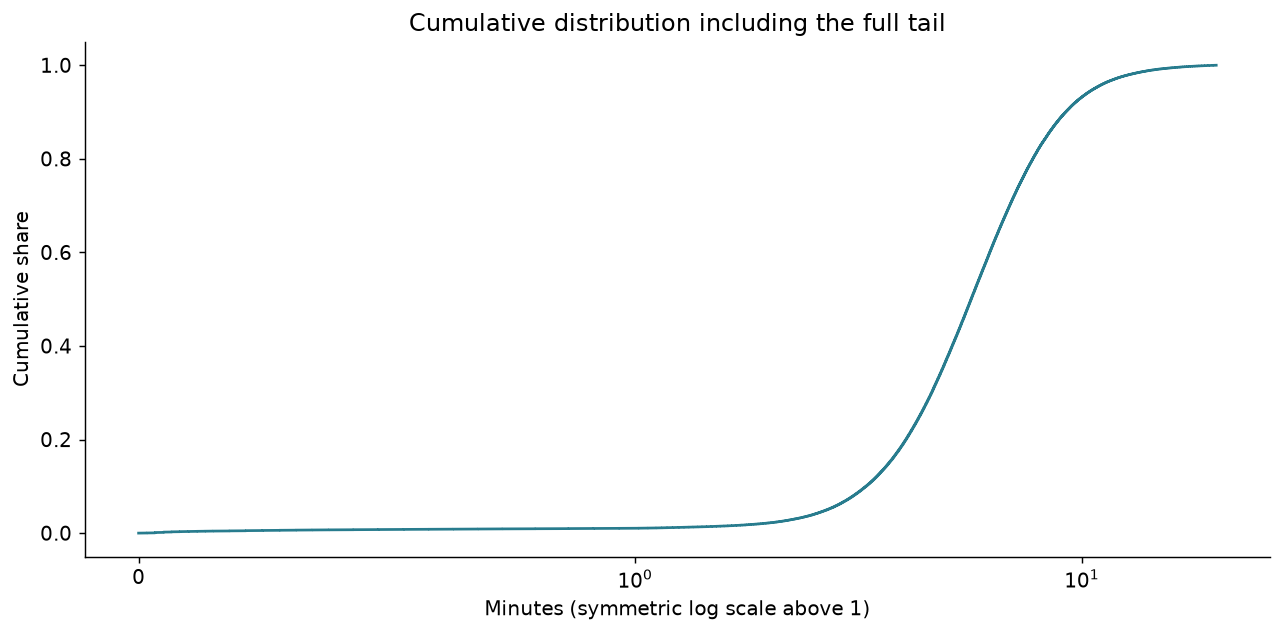

In [9]:
display(Image(filename=str(ROOT/'outputs/figures/03_full_tail.png')))

This cumulative view retains all observed values. The 20-minute ceiling is a property of the source extract, not a cleaning cutoff imposed by this project.

### Monthly pattern

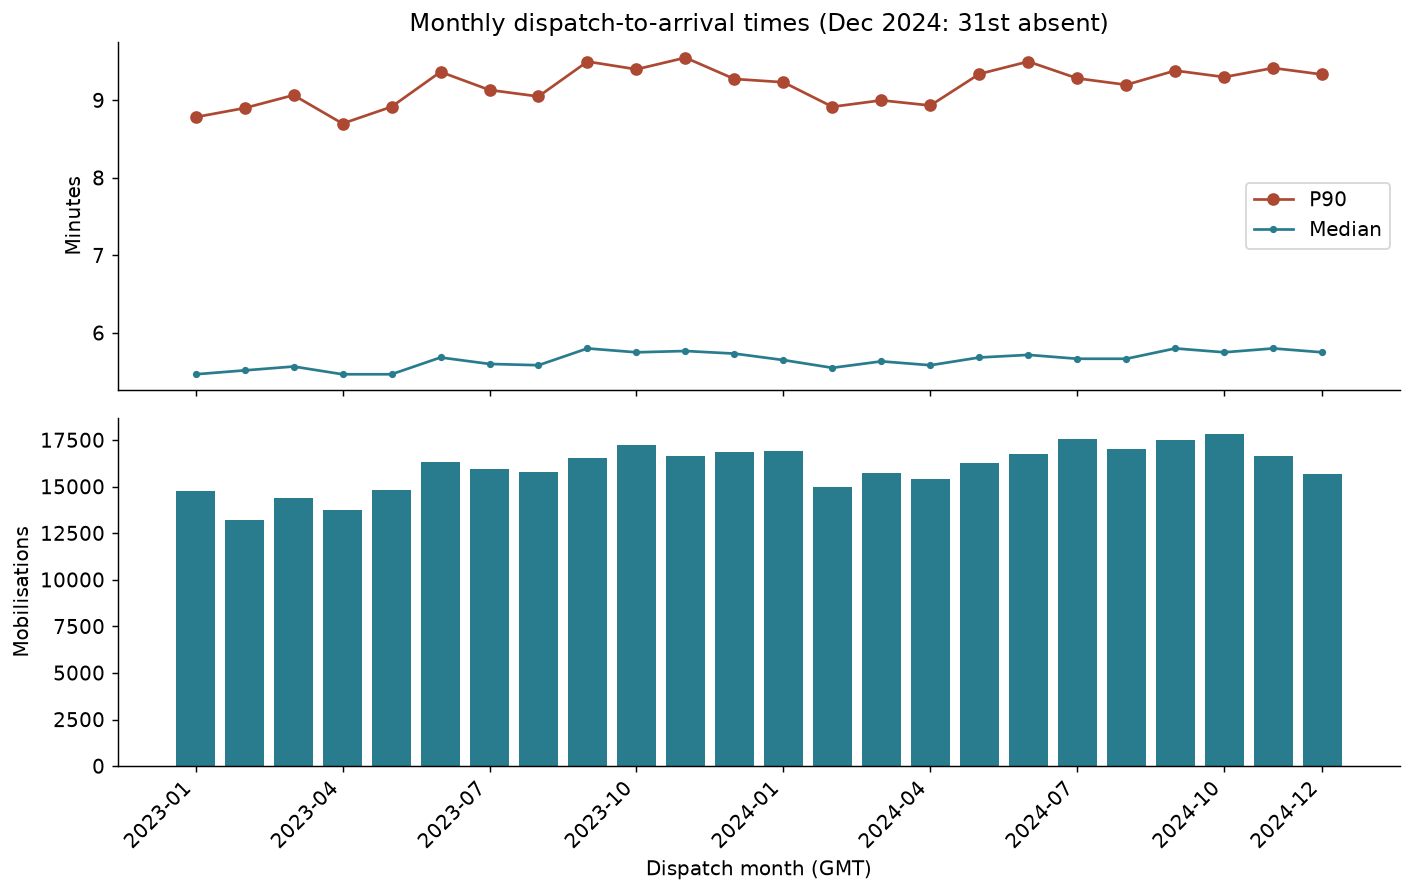

In [10]:
display(Image(filename=str(ROOT/'outputs/figures/04_monthly.png')))

Median and P90 summarise different parts of the distribution. Volume is shown separately. December 2024 is partial; changes are descriptive and do not identify causes.

### Geographic comparison

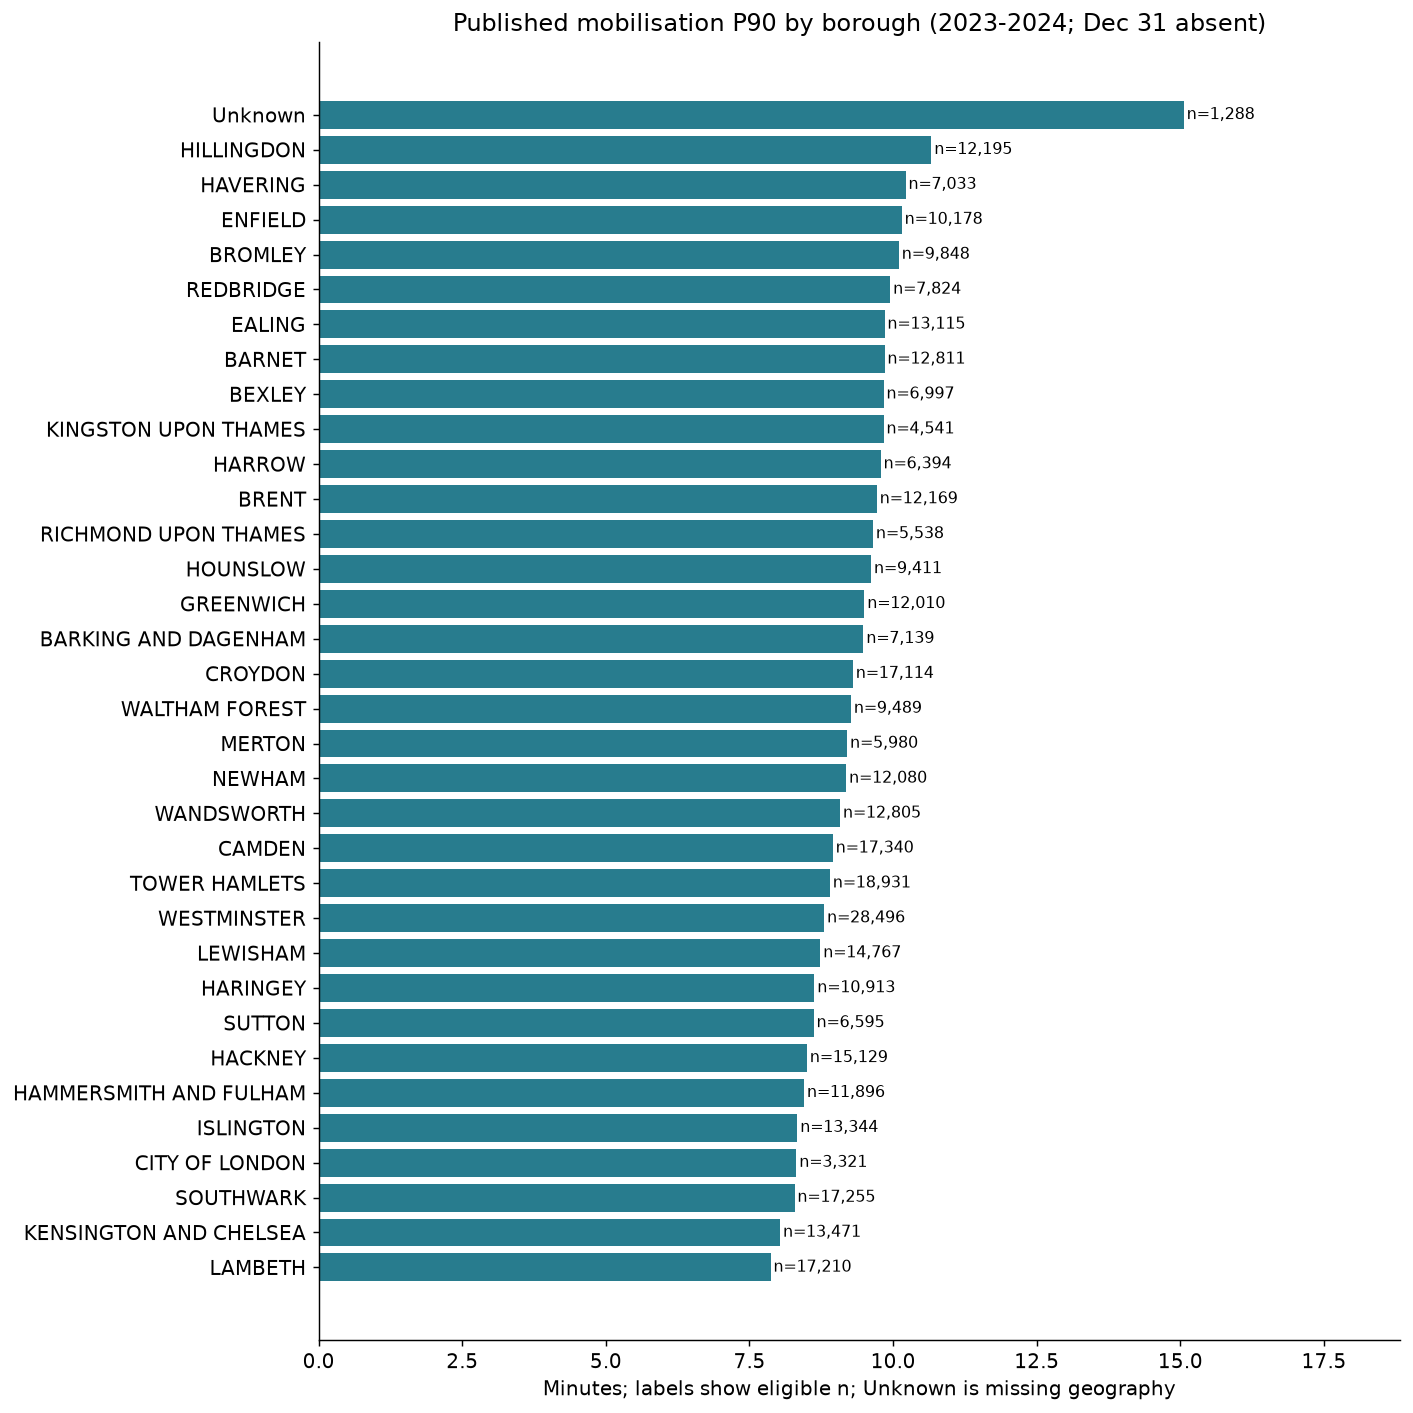

In [11]:
display(Image(filename=str(ROOT/'outputs/figures/05_borough.png')))

Unknown is a data-quality group, not a borough. Different case mix and distances may explain differences; this chart does not rank crew quality.

### Dispatch hour

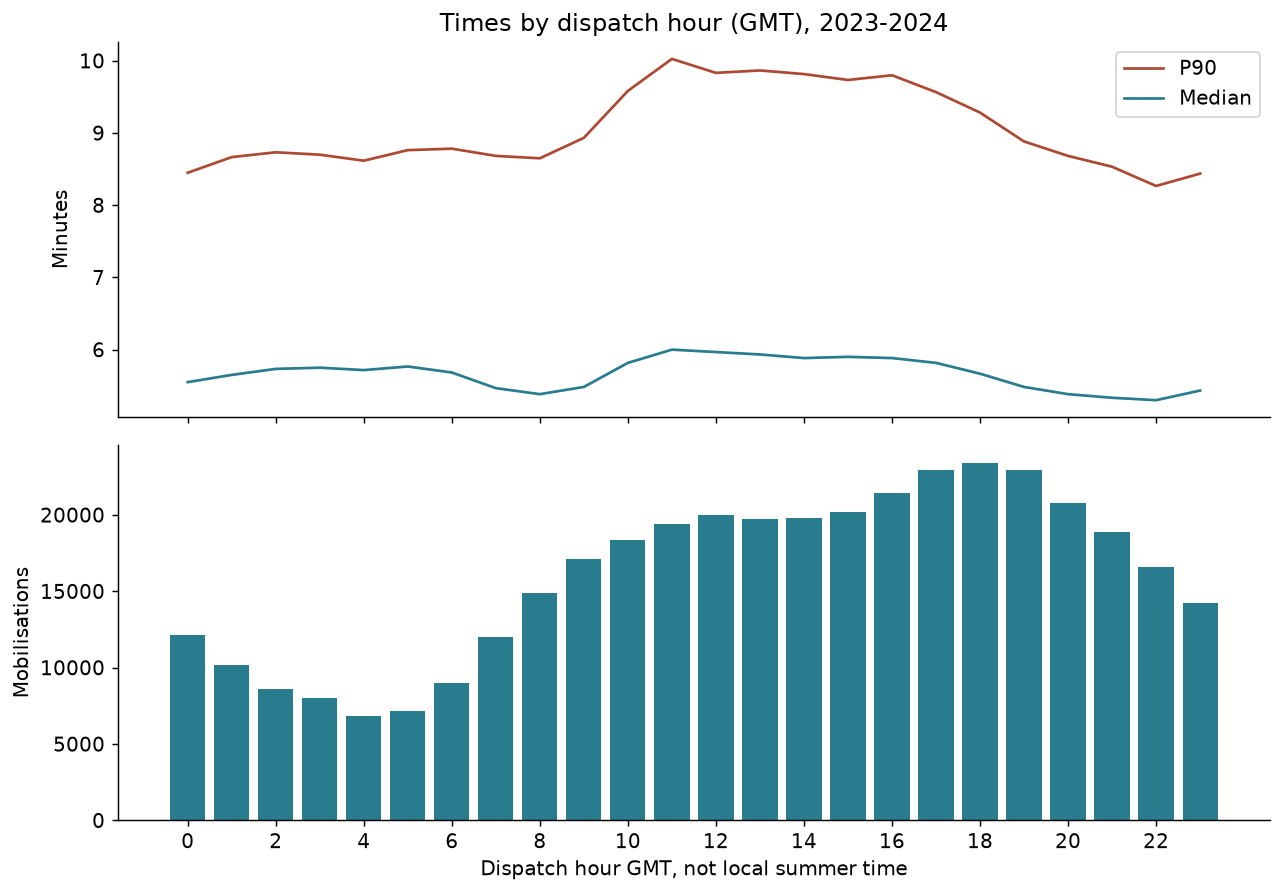

In [12]:
display(Image(filename=str(ROOT/'outputs/figures/06_hour.png')))

Hours use the documented GMT basis rather than local summer time. Longer observed durations at a given hour do not independently establish traffic as the cause.

### Weekday and hour

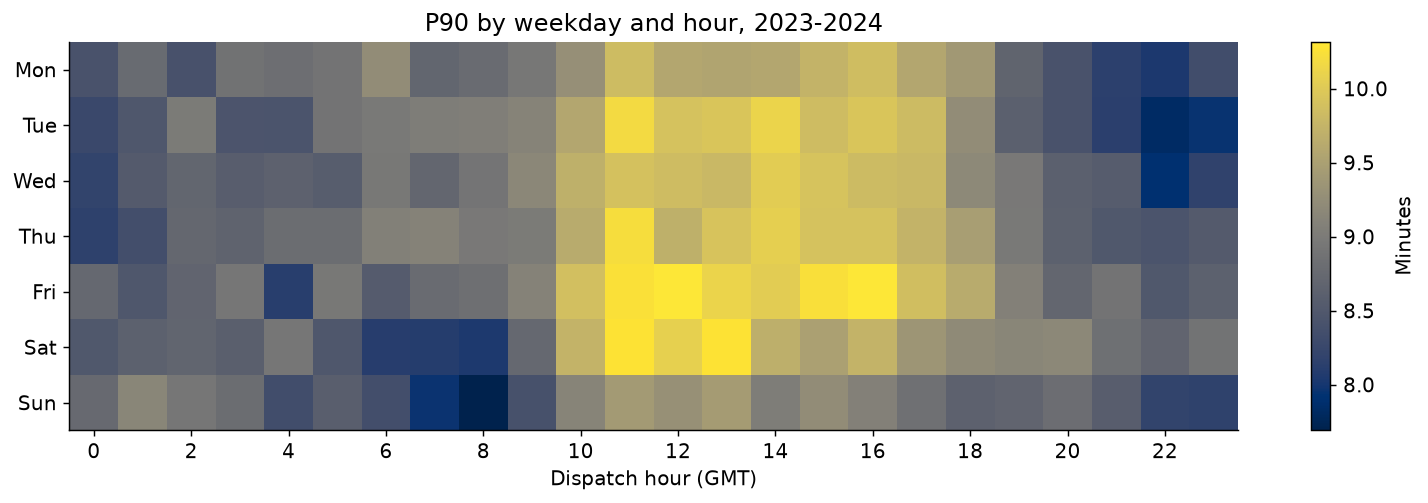

In [13]:
display(Image(filename=str(ROOT/'outputs/figures/07_heatmap.png')))

Each cell pools published records in that weekday/hour combination. This highlights patterns for investigation, without statistical significance claims.

### Correlations

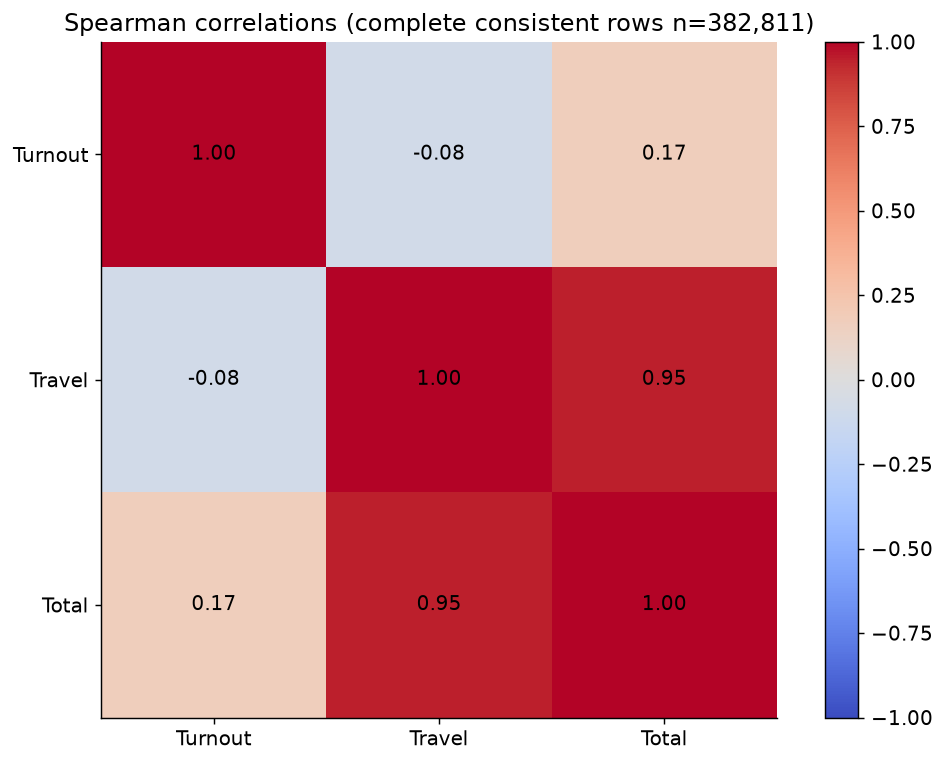

In [14]:
display(Image(filename=str(ROOT/'outputs/figures/08_correlations.png')))

Total attendance contains turnout and travel by construction. Correlation with its components is partly arithmetic and is not causal evidence. Components are unavailable at dispatch and must not become C2 predictors.

### Year comparison

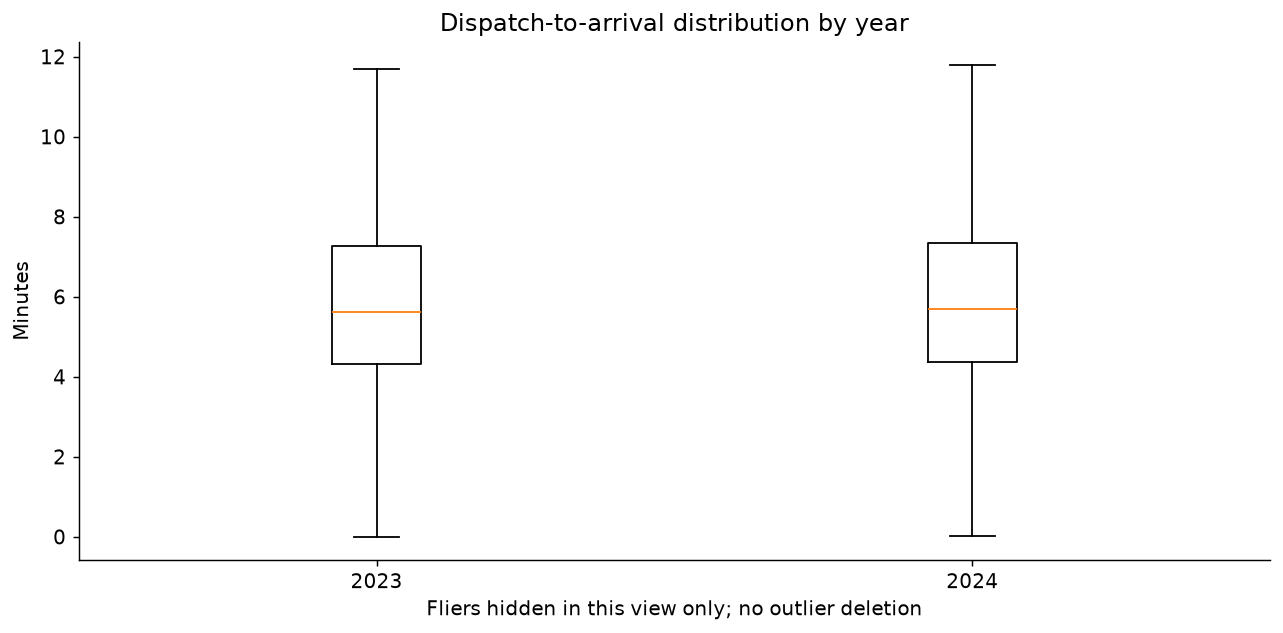

In [15]:
display(Image(filename=str(ROOT/'outputs/figures/09_year_boxplot.png')))

Boxplots hide fliers only for display. All valid rows remain in the KPI. The 2024 total lacks the final calendar day; there is no full-year demand growth claim.

### Exact values and candidate reviews

In [16]:
display(tables['year'])
display(tables['borough'].query("borough != 'Unknown'").sort_values('p90_min',ascending=False).head(5))
display(tables['hour'].sort_values('p90_min',ascending=False).head(5))
display(pd.read_csv(ROOT/'outputs/review_sensitivity.csv'))


,year,n,median_min,p90_min,mean_min
0,2023,186339,5.616667,9.166667,5.995559
1,2024,198288,5.683333,9.25,6.058633


,borough,n,median_min,p90_min,mean_min
16,HILLINGDON,12195,6.633333,10.666667,7.052129
15,HAVERING,7033,6.25,10.216667,6.676011
9,ENFIELD,10178,6.2,10.15,6.605556
4,BROMLEY,9848,6.25,10.1,6.547927
25,REDBRIDGE,7824,6.1,9.95,6.488241


,hour_gmt,n,median_min,p90_min,mean_min
11,11,19425,6.0,10.026667,6.392925
13,13,19755,5.933333,9.866667,6.300417
12,12,19976,5.966667,9.833333,6.313602
14,14,19811,5.883333,9.816667,6.264297
16,16,21411,5.883333,9.8,6.290169


,min_monthly_n,consecutive_months,candidate_boroughs,scope
0,50,3,19,2023-01 to 2024-11; incomplete December excluded
1,50,6,15,2023-01 to 2024-11; incomplete December excluded
2,100,3,19,2023-01 to 2024-11; incomplete December excluded
3,100,6,15,2023-01 to 2024-11; incomplete December excluded
4,200,3,19,2023-01 to 2024-11; incomplete December excluded
5,200,6,15,2023-01 to 2024-11; incomplete December excluded


The proposed rule flags a borough with at least 100 eligible records per month and
P90 above the contemporary global P90 for at least three consecutive months. It is an
academic heuristic, not an LFB target. The sensitivity table changes volume and persistence
requirements and excludes incomplete December 2024. Candidate lists are not staffing orders.


## Takeaways

In [17]:
top=tables['borough'].query("borough != 'Unknown'").sort_values('p90_min',ascending=False).iloc[0]
hour=tables['hour'].sort_values('p90_min',ascending=False).iloc[0]
display(Markdown(f"""1. Among named boroughs, **{top.borough}** has the highest observed P90,
**{top.p90_min:.2f} min**, across **{int(top.n):,}** eligible records.
2. The highest pooled hourly P90 occurs at **{int(hour.hour_gmt):02d}:00 GMT**,
**{hour.p90_min:.2f} min**. This is an association, not a traffic-effect estimate.
3. We recommend reviewing case mix and source eligibility before using these patterns operationally.
4. C2 can compare dispatch-time prediction with a baseline and temporal validation, but cannot
learn the unobserved >20-minute tail from this extract. Do not use arrival, realised travel,
recorded delay reasons or arrival ranking as dispatch-time predictors.
5. Both team members must review the notebook, record their actual contributions and explain
the methods individually. AI assistance is disclosed in PROCESS_LOG.md."""))


1. Among named boroughs, **HILLINGDON** has the highest observed P90,
**10.67 min**, across **12,195** eligible records.
2. The highest pooled hourly P90 occurs at **11:00 GMT**,
**10.03 min**. This is an association, not a traffic-effect estimate.
3. We recommend reviewing case mix and source eligibility before using these patterns operationally.
4. C2 can compare dispatch-time prediction with a baseline and temporal validation, but cannot
learn the unobserved >20-minute tail from this extract. Do not use arrival, realised travel,
recorded delay reasons or arrival ranking as dispatch-time predictors.
5. Both team members must review the notebook, record their actual contributions and explain
the methods individually. AI assistance is disclosed in PROCESS_LOG.md.

### Reproducibility and sources
The original manifest, audited tables, source dictionary and source links are retained.
See `docs/SOURCES.md`, `docs/KPI.md` and `scripts/analysis.py`. Checks compare timestamp
differences with recorded attendance, independently recompute P90 and reconcile group totals.
This does not constitute external verification of every operational record.
